# Quantum Correlations in the Prisoner's Dilemma

Three acts:

1. **Classical PD in quantum language** — product states only; recover the classical Nash equilibrium
2. **EWL: what entanglement changes** — why allowing quantum strategies escapes the trap
3. **Entanglement as a trusted mediator** — the classical price of the quantum apparatus

Dependencies: `numpy`, `matplotlib` only.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── PD payoff values (standard ordering T > R > P > S) ──────────────────────
T, R, P, S = 5, 3, 1, 0

# ── Payoff operators (diagonal in {|CC>, |CD>, |DC>, |DD>} basis) ────────────
PA = np.diag([R, S, T, P]).astype(complex)   # Alice's payoff
PB = np.diag([R, T, S, P]).astype(complex)   # Bob's payoff

## Act 1 — Classical PD in quantum language

A classical mixed strategy is just a cooperation probability $p$. Write Alice's state as:
$$|\psi_A\rangle = \sqrt{p}\,|C\rangle + \sqrt{1-p}\,|D\rangle$$
The amplitudes are real and non-negative — no superposition in the quantum sense, just probability weights packed into a vector. Bob's state $|\psi_B\rangle$ is defined the same way with his own $q$.

The two-player state is the product:
$$|\psi\rangle = |\psi_A\rangle \otimes |\psi_B\rangle$$

The payoff operator for Alice is diagonal in the two-player basis $\{|CC\rangle, |CD\rangle, |DC\rangle, |DD\rangle\}$:
$$\hat{P}_A = \mathrm{diag}(R,\, S,\, T,\, P) = \mathrm{diag}(3,\, 0,\, 5,\, 1)$$

The expected payoff is the sandwich:
$$\langle \hat{P}_A \rangle = \langle\psi|\hat{P}_A|\psi\rangle$$

Because $\hat{P}_A$ is diagonal, only the squared amplitudes (i.e.\ the probabilities) appear — any phase between $|C\rangle$ and $|D\rangle$ drops out. The result is exactly the classical weighted sum $pq\,R + p(1{-}q)\,S + (1{-}p)q\,T + (1{-}p)(1{-}q)\,P$ — no new physics yet, just a notation that carries forward cleanly to Act 2.

In [3]:
def state(p):
    """Classical strategy as amplitude vector: |ψ⟩ = √p|C⟩ + √(1-p)|D⟩"""
    return np.array([np.sqrt(p), np.sqrt(1 - p)], dtype=complex)

def expected_payoff(psi_A, psi_B, payoff_op):
    psi = np.kron(psi_A, psi_B)
    return float(np.real(psi.conj() @ payoff_op @ psi))

# Sanity check: recover the 2×2 payoff matrix
print("Alice's payoff for pure strategy pairs:")
for sa, la in [(1.0, 'C'), (0.0, 'D')]:
    for sb, lb in [(1.0, 'C'), (0.0, 'D')]:
        pi = expected_payoff(state(sa), state(sb), PA)
        print(f"  ({la},{lb}): {pi:.0f}")

Alice's payoff for pure strategy pairs:
  (C,C): 3
  (C,D): 0
  (D,C): 5
  (D,D): 1


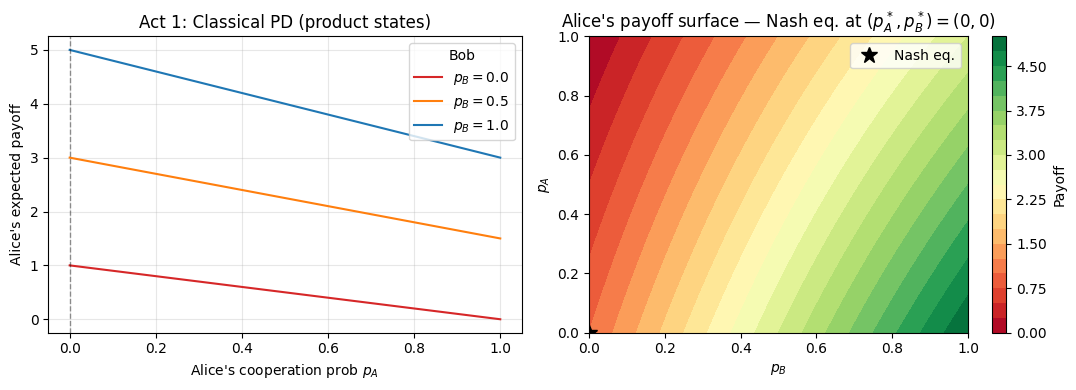

Nash eq. payoff (D,D): Alice=1, Bob=1
Pareto opt. (C,C):     Alice=3, Bob=3


In [4]:
ps = np.linspace(0, 1, 200)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for p_B, color in [(0.0, 'C3'), (0.5, 'C1'), (1.0, 'C0')]:
    axes[0].plot(ps, [expected_payoff(state(p), state(p_B), PA) for p in ps],
                 color=color, label=f'$p_B={p_B}$')

axes[0].axvline(0, color='k', lw=1, ls='--', alpha=0.4)
axes[0].set_xlabel("Alice's cooperation prob $p_A$")
axes[0].set_ylabel("Alice's expected payoff")
axes[0].set_title("Act 1: Classical PD (product states)")
axes[0].legend(title='Bob')
axes[0].grid(alpha=0.3)

# Nash equilibrium surface
PA_grid = np.array([[expected_payoff(state(pA), state(pB), PA)
                     for pB in ps] for pA in ps])
im = axes[1].contourf(ps, ps, PA_grid, levels=20, cmap='RdYlGn')
axes[1].set_xlabel("$p_B$")
axes[1].set_ylabel("$p_A$")
axes[1].set_title("Alice's payoff surface — Nash eq. at $(p_A^*,p_B^*)=(0,0)$")
plt.colorbar(im, ax=axes[1], label='Payoff')
axes[1].plot(0, 0, 'k*', ms=12, label='Nash eq.')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Nash eq. payoff (D,D): Alice={expected_payoff(state(0), state(0), PA):.0f},",
      f"Bob={expected_payoff(state(0), state(0), PB):.0f}")
print(f"Pareto opt. (C,C):     Alice={expected_payoff(state(1), state(1), PA):.0f},",
      f"Bob={expected_payoff(state(1), state(1), PB):.0f}")

**Takeaway:** For every fixed $p_B$, Alice's payoff is highest at $p_A = 0$ (defect). Defection is a dominant strategy — the classical trap holds regardless of Bob's choice.

---

## Act 2 — EWL: a larger strategy space

In the EWL quantum game (Eisert, Wilkens & Lewenstein 1999) the full protocol is:
$$|\psi_f\rangle = J^\dagger\,(U_A \otimes U_B)\,J\,|CC\rangle$$

Three actors, two of which belong to the referee:

- $J$ **(referee, before players):** entangles the neutral starting state into the shared quantum resource $|\Phi\rangle = J|CC\rangle = \tfrac{1}{\sqrt{2}}(|CC\rangle + i|DD\rangle)$.
- $U_A \otimes U_B$ **(players):** each player applies a local unitary to their own qubit — independently, without touching the other's qubit.
- $J^\dagger = J^{-1}$ **(referee, after players):** not a measurement device — simply the inverse of $J$. It returns the state to the classical outcome basis $\{|CC\rangle,|CD\rangle,|DC\rangle,|DD\rangle\}$.

Payoff is then the same sandwich as Act 1: $\langle\psi_f|\hat{P}_A|\psi_f\rangle$. The formula is identical; only the state changes.

$J$ and $J^\dagger$ together bracket the players' moves. Each player's strategy is a 2×2 unitary. Three strategies span the relevant space:

| Strategy | Matrix | Action on single qubit |
|---|---|---|
| $C = I$ | $\begin{pmatrix}1&0\\0&1\end{pmatrix}$ | identity: $\|C\rangle\to\|C\rangle$, $\|D\rangle\to\|D\rangle$ |
| $D = i\sigma_x$ | $\begin{pmatrix}0&i\\i&0\end{pmatrix}$ | bit-flip (quantum NOT): $\|C\rangle\to i\|D\rangle$, $\|D\rangle\to i\|C\rangle$ |
| $\hat{Q} = i\sigma_z$ | $\begin{pmatrix}i&0\\0&-i\end{pmatrix}$ | phase-flip: $\|C\rangle\to i\|C\rangle$, $\|D\rangle\to -i\|D\rangle$ |

$C$ and $D$ are real rotations — $\sigma_x$ is a real matrix and classical probabilities suffice to describe their effect. $\hat{Q} = i\sigma_z$ is purely a phase operation: it leaves the single-qubit measurement probabilities unchanged, but after the $J^\dagger\ldots J$ bracket the relative phase between $|C\rangle$ and $|D\rangle$ shifts the outcome. That is what makes $\hat{Q}$ a genuinely quantum strategy with no classical analogue.

In [5]:
# Entangling operator J at γ = π/2 (referee prepares entangled resource)
J = np.array([
    [1,  0,  0, 1j],
    [0,  1, 1j,  0],
    [0, 1j,  1,  0],
    [1j, 0,  0,  1],
], dtype=complex) / np.sqrt(2)

J_dag = J.conj().T          # J† = J⁻¹: referee un-entangles after players act

CC = np.array([1, 0, 0, 0], dtype=complex)   # |CC⟩ — classical starting point
psi_ent = J @ CC                              # J|CC⟩ = (|CC⟩ + i|DD⟩)/√2

# Pauli matrices (single-qubit building blocks)
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_z = np.diag([1, -1]).astype(complex)

# Strategies: local unitaries each player applies to their own qubit
C_strat = np.eye(2, dtype=complex)   # Cooperate: identity
D_strat = 1j * sigma_x               # Defect:    i·σ_x, swaps |C⟩ ↔ |D⟩
Q_strat = 1j * sigma_z               # Quantum:   i·σ_z, phase-flips |D⟩

def ewl_payoffs(UA, UB):
    """Payoff ⟨ψ_f|P̂|ψ_f⟩ with |ψ_f⟩ = J†(UA⊗UB)J|CC⟩."""
    psi_f = J_dag @ np.kron(UA, UB) @ psi_ent
    piA = float(np.real(psi_f.conj() @ PA @ psi_f))
    piB = float(np.real(psi_f.conj() @ PB @ psi_f))
    return piA, piB

strats = {'C': C_strat, 'D': D_strat, 'Q̂': Q_strat}

# 3×3 payoff table: (Alice payoff, Bob payoff)
print("Payoff table (Alice, Bob) at maximum entanglement:")
print(f"{'':14s}" + "  ".join(f"Bob:{lb:3s}" for lb in strats))
for la, UA in strats.items():
    row = f"Alice:{la:5s} |"
    for lb, UB in strats.items():
        piA, piB = ewl_payoffs(UA, UB)
        row += f"  ({piA:.0f},{piB:.0f})  "
    print(row)

Payoff table (Alice, Bob) at maximum entanglement:
              Bob:C    Bob:D    Bob:Q̂ 
Alice:C     |  (3,3)    (0,5)    (1,1)  
Alice:D     |  (5,0)    (1,1)    (0,5)  
Alice:Q̂    |  (1,1)    (5,0)    (3,3)  


In [6]:
# Verify: do classical strategies land on classical basis states?
print("Final-state probabilities  P(outcome) = |⟨outcome|ψ_f⟩|²")
print(f"{'':12s}  {'P(CC)':>6}  {'P(CD)':>6}  {'P(DC)':>6}  {'P(DD)':>6}   payoff_A")
for la, UA in strats.items():
    for lb, UB in strats.items():
        psi_f = J_dag @ np.kron(UA, UB) @ psi_ent
        probs = np.abs(psi_f) ** 2
        piA = float(np.real(psi_f.conj() @ PA @ psi_f))
        prob_str = "  ".join(f"{p:6.2f}" for p in probs)
        print(f"  ({la},{lb}):  {prob_str}   {piA:.0f}")

Final-state probabilities  P(outcome) = |⟨outcome|ψ_f⟩|²
               P(CC)   P(CD)   P(DC)   P(DD)   payoff_A
  (C,C):    1.00    0.00    0.00    0.00   3
  (C,D):    0.00    1.00    0.00    0.00   0
  (C,Q̂):    0.00    0.00    0.00    1.00   1
  (D,C):    0.00    0.00    1.00    0.00   5
  (D,D):    0.00    0.00    0.00    1.00   1
  (D,Q̂):    0.00    1.00    0.00    0.00   0
  (Q̂,C):    0.00    0.00    0.00    1.00   1
  (Q̂,D):    0.00    0.00    1.00    0.00   5
  (Q̂,Q̂):    1.00    0.00    0.00    0.00   3


**Why the rules haven't changed — and why $(\hat{Q}, D)$ lands on $|DC\rangle$**

There are two distinct things to track:

- **Strategy** — what each player chose. Here: Alice chose $\hat{Q}$, Bob chose $D$.
- **Outcome state** — which of $\{|CC\rangle, |CD\rangle, |DC\rangle, |DD\rangle\}$ the final state occupies after the full $J^\dagger\ldots J$ protocol. The payoff rule is: *whatever outcome state is occupied, assign the classical PD payoff for that outcome.* The label "$DC$" means Alice gets $T$ and Bob gets $S$ — it does **not** mean Alice's strategy was $D$.

For $(\hat{Q}, D)$, step by step (using $\hat{Q}|C\rangle = i|C\rangle$, $\hat{Q}|D\rangle = -i|D\rangle$, $D|C\rangle = i|D\rangle$, $D|D\rangle = i|C\rangle$):

$$J|CC\rangle = \tfrac{1}{\sqrt{2}}\bigl(|CC\rangle + i|DD\rangle\bigr)$$

$$(\hat{Q}\otimes D)|CC\rangle = i|C\rangle\otimes i|D\rangle = i^2|CD\rangle = -|CD\rangle$$

$$(\hat{Q}\otimes D)|DD\rangle = {-i}|D\rangle\otimes i|C\rangle = -i^2|DC\rangle = +|DC\rangle$$

$$(\hat{Q}\otimes D)\,J|CC\rangle = \tfrac{1}{\sqrt{2}}\bigl(-|CD\rangle + i|DC\rangle\bigr)$$

$J^\dagger$ maps this back to the outcome basis. The two terms **interfere**: the $-|CD\rangle$ component cancels and the $|DC\rangle$ component survives, leaving $i|DC\rangle$ (global phase, irrelevant to payoffs).

**Outcome: $|DC\rangle$ with probability 1.** Alice receives $T=5$, Bob receives $S=0$ — exactly the classical payoffs for the $DC$ outcome. But Alice never flipped her qubit. $\hat{Q}$ exploited the phase correlations built by $J$: without entanglement, $\hat{Q}$'s phase operation would have no effect on occupation probabilities. With entanglement, it redirects $D$'s bit-flip so the $|CD\rangle$ term (Bob benefits) cancels and the $|DC\rangle$ term (Alice benefits) doubles.

For every classical strategy pair the final state is a single basis state — certainty, not superposition. The $J^\dagger\ldots J$ bracket "un-entangles" classical strategies back to deterministic outcomes, so the payoff sandwich $\langle\psi_f|\hat{P}_A|\psi_f\rangle$ simply reads off the diagonal entry for that outcome. Entanglement adds nothing for players who stay classical.

$\hat{Q}$ against $D$ is the key: $(\hat{Q}, D)$ also lands on $|DC\rangle$ with certainty — Alice gets $T=5$ against a defector without herself defecting. That is the new degree of freedom. Because $\hat{Q}$ beats $D$, defection is no longer dominant, and the classical trap breaks.

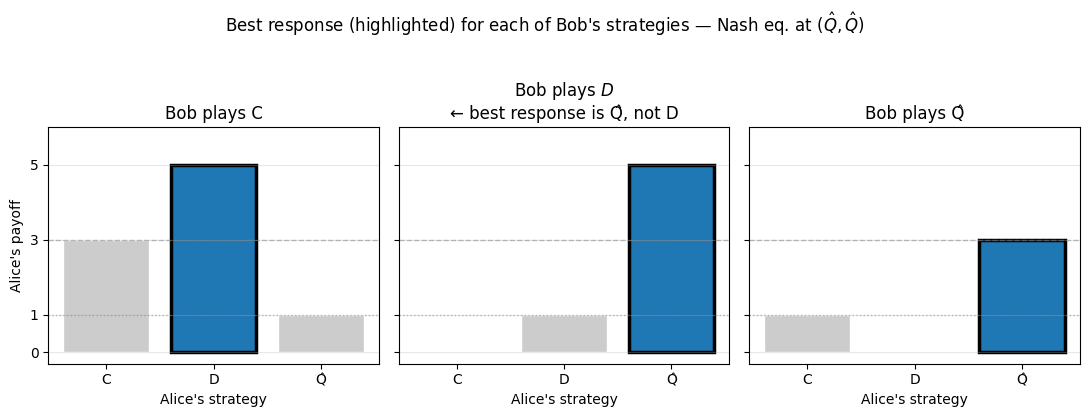

Nash equilibrium check:
  Nash eq: (Q̂,Q̂) → payoff (3,3)


In [7]:
strat_labels = list(strats.keys())

fig, axes = plt.subplots(1, 3, figsize=(11, 4), sharey=True)

for ax, (bob_name, UB) in zip(axes, strats.items()):
    alice_payoffs = [ewl_payoffs(UA, UB)[0] for UA in strats.values()]
    best_idx = int(np.argmax(alice_payoffs))
    colors = ['#cccccc'] * 3
    colors[best_idx] = 'C0'
    bars = ax.bar(strat_labels, alice_payoffs, color=colors, edgecolor='white')
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.5)
    ax.axhline(R, color='gray', lw=1, ls='--', alpha=0.5)
    ax.axhline(P, color='gray', lw=1, ls=':', alpha=0.5)
    ax.set_title(f"Bob plays {bob_name}")
    ax.set_xlabel("Alice's strategy")
    ax.set_ylim(-0.3, 6)
    ax.set_yticks([0, 1, 3, 5])
    ax.grid(alpha=0.3, axis='y')

axes[0].set_ylabel("Alice's payoff")
axes[1].set_title(r"Bob plays $D$" + "\n← best response is Q̂, not D")
plt.suptitle(r"Best response (highlighted) for each of Bob's strategies — Nash eq. at $(\hat{Q},\hat{Q})$",
             y=1.03)
plt.tight_layout()
plt.show()

print("Nash equilibrium check:")
for la, UA in strats.items():
    for lb, UB in strats.items():
        alice_best = strat_labels[int(np.argmax([ewl_payoffs(UA2, UB)[0] for UA2 in strats.values()]))]
        bob_best   = strat_labels[int(np.argmax([ewl_payoffs(UA, UB2)[1] for UB2 in strats.values()]))]
        is_nash = (alice_best == la and bob_best == lb)
        if is_nash:
            piA, piB = ewl_payoffs(UA, UB)
            print(f"  Nash eq: ({la},{lb}) → payoff ({piA:.0f},{piB:.0f})")

**What $\hat{Q}$ does in practice** (read from the final-state table above):

| Pair | Outcome | Alice | Bob |
|---|---|---|---|
| $(\hat{Q}, D)$ | $\|DC\rangle$ | $T = 5$ | $S = 0$ |
| $(\hat{Q}, \hat{Q})$ | $\|CC\rangle$ | $R = 3$ | $R = 3$ |
| $(\hat{Q}, C)$ | $\|DD\rangle$ | $P = 1$ | $P = 1$ |

When Bob defects, $\hat{Q}$ turns the tables: the outcome is $|DC\rangle$ with certainty — Alice receives the defector's payoff $T=5$ and Bob receives the sucker's payoff $S=0$, as if their roles had swapped. $\hat{Q}$ is not a classical defection (Alice's qubit does not flip to $|D\rangle$) but after the $J^\dagger\ldots J$ bracket the phase rotation lands in exactly the same outcome. $\hat{Q}$ is not "mirror Bob's strategy" either: when Bob cooperates, $(\hat{Q},C)$ gives mutual-defection outcome $|DD\rangle$ with $P=1$ for both.

**Why $(\hat{Q},\hat{Q})$ is a Nash equilibrium:** if Alice deviates to $D$, the outcome is $(D,\hat{Q}) \to |CD\rangle$ giving her $S=0$. If she deviates to $C$, $(C,\hat{Q}) \to |DD\rangle$ giving her $P=1$. Both are worse than staying at $R=3$. By symmetry the same holds for Bob. Neither player gains by deviating unilaterally — and the equilibrium payoff $(R,R)=(3,3)$ is Pareto optimal.

The deeper question: is entanglement strictly necessary to achieve these outcomes, or can a purely classical resource — shared randomness plus a single communicated bit — produce the same correlations?

**What $\hat{Q}$ really is — the scoreboard rule**

The interference story can be replaced by an exact classical rule. The key is the algebraic form of the entangler:
$$J = \tfrac{1}{\sqrt{2}}\bigl(I + i\,\sigma_x\!\otimes\!\sigma_x\bigr)$$

Any local operation either commutes or anticommutes with $\sigma_x\!\otimes\!\sigma_x$, and that decides what the bracket $J^\dagger(\cdot)J$ does to it:

- **$C$ (identity):** passes through, contributes nothing.
- **$D$ (bit-flip):** $\sigma_x$ commutes with $\sigma_x\!\otimes\!\sigma_x$ → passes through unchanged. Effect: **flips your own letter** on the scoreboard.
- **$\hat{Q}$ (phase-flip):** $\sigma_z$ *anticommutes* → the bracket converts it. One line of Pauli algebra gives

$$
J^\dagger(\sigma_z\!\otimes\!I)\,J = -i\,(\sigma_x\sigma_z)\!\otimes\!\sigma_x
$$

a **double bit-flip**. Effect: **flips both letters** on the scoreboard.

Every entry in the payoff table now follows from composing flips classically — start at "CC", apply the flips, read off the classical payoffs:

| Pair | Flips on "CC" | Scoreboard | Payoffs |
|---|---|---|---|
| $(\hat{Q}, C)$ | both | DD | $(P, P) = (1,1)$ |
| $(\hat{Q}, D)$ | both + Bob's own | Bob's cancels → DC | $(T, S) = (5,0)$ |
| $(\hat{Q}, \hat{Q})$ | both + both = none | CC | $(R, R) = (3,3)$ |

This is not a metaphor — the rule is exact (the code cell below verifies the operator identity to machine precision).

**The strategic reading:** $D$ means *flip my letter* (grab the temptation payoff). $\hat{Q}$ means *"flip both our letters"* — it ties the two ledgers together. Against a defector, your $\hat{Q}$ flips his letter *back*: his defection mark is erased and the flip lands on your letter instead, so the scoreboard reads DC and you collect $T=5$. Two $\hat{Q}$ s cancel, leaving the cooperative start untouched. Defection becomes self-defeating against a $\hat{Q}$-player — punishment is built into the move itself, executed simultaneously, with no communication and no time ordering. That is the precise version of the "built-in tit-for-tat" description sometimes used for $\hat{Q}$.

In [ ]:
# Verify the scoreboard rule as operator identities (exact, up to global phase)
I2 = np.eye(2, dtype=complex)

# J has the advertised algebraic form
print("J = (I + i·σx⊗σx)/√2:",
      np.allclose(J, (np.eye(4) + 1j * np.kron(sigma_x, sigma_x)) / np.sqrt(2)))

# Bit-flips commute with σx⊗σx → pass through the bracket unchanged
print("J†(I⊗σx)J = I⊗σx:    ",
      np.allclose(J_dag @ np.kron(I2, sigma_x) @ J, np.kron(I2, sigma_x)))

# Phase-flip anticommutes → becomes a double bit-flip
eff = J_dag @ np.kron(sigma_z, I2) @ J
target = np.kron(sigma_x @ sigma_z, sigma_x)
print("J†(σz⊗I)J = -i·(σxσz⊗σx):", np.allclose(eff, -1j * target))

# Scoreboard rule reproduces the outcomes: compose flips on |CC⟩
labels = ['CC', 'CD', 'DC', 'DD']
for name, U in [('(Q̂,C)', np.kron(Q_strat, C_strat)),
                ('(Q̂,D)', np.kron(Q_strat, D_strat)),
                ('(Q̂,Q̂)', np.kron(Q_strat, Q_strat))]:
    out = J_dag @ U @ J @ CC
    print(f"  {name} → {labels[int(np.argmax(np.abs(out)**2))]}")

## Act 3 — Entanglement as a trusted mediator

The EWL quantum game enlarges the strategy space from $\{C, D\}$ to $\{C, D, \hat{Q}\}$. But $\hat{Q}$ is not a player invention — it is a valid operation only because the referee provides $J$ and $J^\dagger$. Without the referee's apparatus, Alice and Bob have only $\{C, D\}$.

**The classical analog.** Replace $J$ and $J^\dagger$ with a **trusted mediator M**:

    Pre-game:  Alice, Bob, M agree on the outcome table below.
    
    Game:
      Alice ─── s_A (sealed) ───▶  M  ◀─── s_B (sealed) ─── Bob
                     (both slips arrive; M opens nothing until both are held)
      M looks up (s_A, s_B) in the outcome table, pays Alice π_A and Bob π_B.

The outcome table M enforces — identical to the EWL quantum payoff table:

| | Bob: C | Bob: D | Bob: $Q_c$ |
|---|---|---|---|
| **Alice: C** | (3, 3) | (0, 5) | (1, 1) |
| **Alice: D** | (5, 0) | (1, 1) | (0, 5) |
| **Alice: $Q_c$** | (1, 1) | (5, 0) | (3, 3) |

$Q_c$ is a label whose meaning comes entirely from M's table. M's enforceability is what makes writing $Q_c$ rational: defecting against $Q_c$ gives $S=0$; both playing $Q_c$ gives $R=3$. The mediator makes the punishment credible.

This equivalence is a known result: **van Enk & Pike (PRA 66, 024306, 2002, "Classical rules in quantum games")** pointed out that the EWL game with discrete strategies is exactly a classical 3×3 game with an enlarged strategy set — the cooperative equilibrium comes from the enlarged contract space, not from quantum mechanics per se. The genuinely quantum content only appears when the full continuous strategy space is allowed (below).

**Why this is the right analogy.** Frąckiewicz (2011, [arXiv:1101.3380](https://arxiv.org/abs/1101.3380)) proves formally that Nash equilibria in EWL-type quantum games are classical **correlated equilibria** (Aumann 1974): the entanglement apparatus plays the mathematical role of a correlation device that recommends strategies to each player. $J$ prepares the correlated resource; $J^\dagger$ decodes it into an outcome. A trusted mediator implements the same logic classically.

**The cost of removing entanglement.** For discrete $\{C, D, Q_c\}$, all outcomes are deterministic (probability 1 on specific basis states — verified in the table above), so M's lookup table needs no randomness and no communication. This changes if players choose from the *full continuous* strategy space $U(\theta,\phi,\gamma) \in SU(2)$: outcomes become probabilistic, Bell's theorem applies, and local hidden variables alone cannot reproduce the quantum correlations. Toner-Bacon (2003) shows the minimal classical price is exactly **1 bit** from Alice to M:

    Pre-game: M generates shared seed λ (distributed to Alice and Bob).
    Game:     Alice sends U_A + one bit  b(U_A, λ)  to M.
              Bob sends U_B to M.
              M uses (U_B, λ, b) to sample the correct outcome distribution.

Without $b$, M cannot exceed the CHSH bound — Bell's theorem forbids it. With $b$, M reproduces every quantum correlation exactly (Toner-Bacon theorem). The quantum apparatus $J/J^\dagger$ replaces this explicit communication by building the correlation into the physics.

In [8]:
# Classical mediator protocol — verify the same Nash equilibrium without any quantum physics
# M enforces the outcome table: identical to J†(UA⊗UB)J for discrete {C, D, Qc}

qc_outcomes = {
    ('C',  'C'):   (R, R),
    ('C',  'D'):   (S, T),
    ('C',  'Qc'):  (P, P),
    ('D',  'C'):   (T, S),
    ('D',  'D'):   (P, P),
    ('D',  'Qc'):  (S, T),
    ('Qc', 'C'):   (P, P),
    ('Qc', 'D'):   (T, S),
    ('Qc', 'Qc'):  (R, R),
}
strats_c = ['C', 'D', 'Qc']

print("Classical mediator payoff table (matches EWL quantum table above):")
print(f"{'':12s}" + "  ".join(f"Bob:{s:3s}" for s in strats_c))
for sA in strats_c:
    row = f"Alice:{sA:4s} |"
    for sB in strats_c:
        pA, pB = qc_outcomes[(sA, sB)]
        row += f"  ({pA},{pB})  "
    print(row)

print("\nNash equilibrium (exhaustive unilateral deviation check):")
for sA in strats_c:
    for sB in strats_c:
        pA0, pB0 = qc_outcomes[(sA, sB)]
        alice_best = max(qc_outcomes[(s, sB)][0] for s in strats_c if s != sA)
        bob_best   = max(qc_outcomes[(sA, s)][1] for s in strats_c if s != sB)
        tag = "  ← unique Nash eq." if alice_best <= pA0 and bob_best <= pB0 else ""
        print(f"  ({sA:3s},{sB:3s}): ({pA0},{pB0}){tag}")

Classical mediator payoff table (matches EWL quantum table above):
            Bob:C    Bob:D    Bob:Qc 
Alice:C    |  (3,3)    (0,5)    (1,1)  
Alice:D    |  (5,0)    (1,1)    (0,5)  
Alice:Qc   |  (1,1)    (5,0)    (3,3)  

Nash equilibrium (exhaustive unilateral deviation check):
  (C  ,C  ): (3,3)
  (C  ,D  ): (0,5)
  (C  ,Qc ): (1,1)
  (D  ,C  ): (5,0)
  (D  ,D  ): (1,1)
  (D  ,Qc ): (0,5)
  (Qc ,C  ): (1,1)
  (Qc ,D  ): (5,0)
  (Qc ,Qc ): (3,3)  ← unique Nash eq.


**The mediator in economic terms**

The mediated $3\times 3$ game is a well-known structure in economics — with one refinement worth making first. Look at the $(Q_c, D)$ entry: Bob submits "defect" and ends up with the sucker payoff $S=0$, his chosen action effectively overridden. A mediator who merely *recommends* strategies (which players may ignore) can never do that. So M is an **enforcer, not an advisor** — an institution with sanctioning power, not a correlation device in the narrow Aumann sense. In the quantum game, unitarity is the sanction: physics itself plays the Leviathan.

Three economic literatures map onto this game:

**1. Mediated games and commitment devices.** Aumann (1974) introduced the mediator into game theory (correlated equilibrium); Forges (1986) and Myerson (1986) developed the general theory of games played through a mediator. The closest match is **Tennenholtz's "program equilibrium" (Games and Economic Behavior, 2004)**: each player submits a *program* to a trusted computer, and programs can read each other — "cooperate iff your program equals mine, else defect" makes one-shot PD cooperation an equilibrium. Submitting that program is essentially choosing $Q_c$. See also Fershtman, Judd & Kalai (1991) on strategic delegation, Kalai, Kalai, Lehrer & Samet (2010) "A commitment folk theorem," and Schelling's *Strategy of Conflict* (1960) for the root idea: $Q_c$ is a commitment device.

**2. Institutions and the commons.** The intuition "the mediator is a regulator that lets fishers escape the common-pool trap" is precisely the experimental institutional-economics literature:

- Ostrom, Walker & Gardner (1992, *APSR*), **"Covenants with and without a sword"** — common-pool resource games where adding a sanctioning option transforms outcomes; the title is exactly the advisor/enforcer distinction.
- Gürerk, Irlenbusch & Rockenbach (2006, *Science*), "The competitive advantage of sanctioning institutions" — players choose between a sanction-free and a sanctioning institution, and migrate to the sanctioning one over time. *Choosing the institution is choosing $Q_c$.*
- Kosfeld, Okada & Riedl (2009, *AER*), "Institution formation in public goods games" — players endogenously create the punishing institution.
- Ostrom (1990), *Governing the Commons* — the book-length version.

**3. Punishment sustains cooperation.** Boyd & Richerson (1992); Fehr & Gächter (2000, *AER*; 2002, *Nature*, "Altruistic punishment in humans") — adding a punishment option to public-goods experiments flips defection equilibria to cooperation; Sigmund, De Silva, Traulsen & Hauert (2010, *Nature*) — "pool punishment," where paying into a sanctioning institution outcompetes peer punishment.

The chain this notebook traces is therefore: **EWL quantum game → (van Enk & Pike) classical $3\times3$ mediated game → (this literature) institution-formation game of the Ostrom type.** The quantum twist stays where it was: economists must build the Leviathan and trust it; in EWL the enforcement is carried out by the unitarity of $J^\dagger\ldots J$, and Toner-Bacon prices the classical replacement of that physics at exactly one bit.